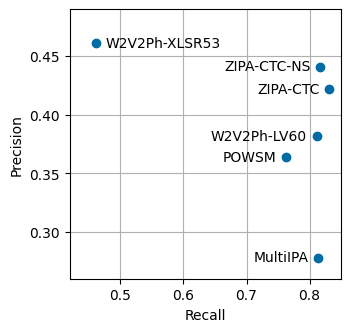

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

plt.style.use("tableau-colorblind10")

df = pd.read_csv(
    StringIO(
        """Model	ModelString	Setup	Dataset	 Original f1	Recalc F1	precision	recall
anyspeech/zipa-large-crctc-500k	ZIPA-CTC	Probing	Doreco-45	0.552	0.560	0.422	0.831
anyspeech/zipa-large-crctc-ns-800k	ZIPA-CTC-NS	Probing	Doreco-45	0.566	0.573	0.441	0.817
espnet/powsm	POWSM	Probing	Doreco-45	0.487	0.493	0.364	0.763
ctaguchi/wav2vec2-large-xlsr-japlmthufielta-ipa1000-ns	MultiIPA	Probing	Doreco-45	0.409	0.414	0.278	0.813
facebook/wav2vec2-lv-60-espeak-cv-ft	W2V2Ph-LV60	Probing	Doreco-45	0.513	0.519	0.382	0.811
facebook/wav2vec2-xlsr-53-espeak-cv-ft	W2V2Ph-XLSR53	Probing	Doreco-45	0.569	0.461	0.461	0.461"""
    ),
    sep="\t",
)

plt.figure(figsize=(3.5, 3.5))
plt.scatter(df["recall"], df["precision"], c="C0")
plt.grid(True)

for _, row in df.iterrows():
    align = "left" if row["ModelString"] == "W2V2Ph-XLSR53" else "right"
    plt.text(
        row["recall"] + 0.015 * (1 if align == "left" else -1),
        row["precision"],
        row["ModelString"],
        fontsize=10,
        ha=align,
        va="center",
    )
plt.xlim(0.42, 0.85)
plt.ylim(0.26, 0.49)
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.savefig("pr-scatter.pdf", bbox_inches="tight")